In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

#set project root as .../recidivism-causal
project_root = Path("/dcs/23/u2200504/thesis/recidivism-causal").resolve()

#set causal pitfalls root
cp_root = project_root / "data" / "raw" / "CausalPitfallsData"
#test it works
cp_root

score_dir = project_root/"results"/"scores"

In [3]:
files = {
    "dagbagm": score_dir/"scores_dagbagm.csv",
    "dagslam": score_dir/"scores_dagslam.csv",
    "fci": score_dir/"scores_fci.csv",
    "hc": score_dir/"scores_hc.csv",
    "lim": score_dir/"scores_lim.csv",
    "rex": score_dir/"scores_rex.csv"
}

dfs = []
for algo, path in files.items():
    df = pd.read_csv(path)
    dfs.append(df)

all_scores = pd.concat(dfs, ignore_index=True, sort=False)

In [4]:
all_scores_path = score_dir / "scores_all_algos.csv"
all_scores.to_csv(all_scores_path, index=False)

In [5]:
all_scores = all_scores.sort_values(
    by=["dataset", "algo"], ascending=[True, True]
).reset_index(drop=True)

all_scores.head()

,TP,FP,FN,TN,SHD,TPR,FPR,FDR,scenario,dataset,...,skel_FPR,skel_FDR,orient_TP,orient_FP,orient_FN,orient_TN,orient_SHD,orient_TPR,orient_FPR,orient_FDR
0,2.0,0.0,1.0,6.0,1.0,0.666667,0.000000,0.00,moderation_effect,arthritis_pain_reduction,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3.0,1.0,0.0,5.0,1.0,1.000000,0.166667,0.25,moderation_effect,arthritis_pain_reduction,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,moderation_effect,arthritis_pain_reduction,...,0.0,0.0,4.0,0.0,2.0,0.0,2.0,0.666667,NaN,0.0
3,2.0,0.0,1.0,6.0,1.0,0.666667,0.000000,0.00,moderation_effect,arthritis_pain_reduction,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0,0.0,0.0,6.0,0.0,1.000000,0.000000,0.00,moderation_effect,arthritis_pain_reduction,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
all_scores.columns

Index(['TP', 'FP', 'FN', 'TN', 'SHD', 'TPR', 'FPR', 'FDR', 'scenario',
       'dataset', 'algo', 'skel_TP', 'skel_FP', 'skel_FN', 'skel_TN',
       'skel_SHD', 'skel_TPR', 'skel_FPR', 'skel_FDR', 'orient_TP',
       'orient_FP', 'orient_FN', 'orient_TN', 'orient_SHD', 'orient_TPR',
       'orient_FPR', 'orient_FDR'],
      dtype='object')

In [14]:
#use skel_TP, skel_FP, skel_FN, etc as standard metrics for fci runs
fci_experiments=all_scores["algo"] == "fci"
for metric in ["TP", "FP", "FN", "TN", "SHD", "TPR", "FPR", "FDR"]:
    all_scores.loc[fci_experiments, metric] = np.where(
        all_scores.loc[fci_experiments, metric].isna(),
        all_scores.loc[fci_experiments, f"skel_{metric}"],
        all_scores.loc[fci_experiments, metric])

In [13]:
all_scores.loc[fci_experiments]

,TP,FP,FN,TN,SHD,TPR,FPR,FDR,scenario,dataset,...,skel_FPR,skel_FDR,orient_TP,orient_FP,orient_FN,orient_TN,orient_SHD,orient_TPR,orient_FPR,orient_FDR
2,4.0,0.0,2.0,3.0,2.0,0.666667,0.000000,0.000000,moderation_effect,arthritis_pain_reduction,...,0.000000,0.000000,4.0,0.0,2.0,0.0,2.0,0.666667,NaN,0.000000
8,4.0,0.0,6.0,6.0,6.0,0.400000,0.000000,0.000000,domain_shift,arthritis_trial,...,0.000000,0.000000,4.0,0.0,6.0,0.0,6.0,0.400000,NaN,0.000000
14,6.0,0.0,0.0,10.0,0.0,1.000000,0.000000,0.000000,necessity_sufficiency,bridge_integrity,...,0.000000,0.000000,6.0,0.0,0.0,0.0,0.0,1.000000,NaN,0.000000
20,4.0,0.0,6.0,6.0,6.0,0.400000,0.000000,0.000000,domain_shift,cardio_trial,...,0.000000,0.000000,4.0,0.0,6.0,0.0,6.0,0.400000,NaN,0.000000
26,4.0,0.0,6.0,6.0,6.0,0.400000,0.000000,0.000000,domain_shift,cholesterol_trial,...,0.000000,0.000000,4.0,0.0,6.0,0.0,6.0,0.400000,NaN,0.000000
32,6.0,0.0,2.0,8.0,2.0,0.750000,0.000000,0.000000,counterfactual_reasoning,climate_impact_sem,...,0.000000,0.000000,0.0,0.0,8.0,0.0,8.0,0.000000,NaN,NaN
40,6.0,2.0,0.0,8.0,2.0,1.000000,0.200000,0.250000,causal_direction_iv,clinical_trial_sem,...,0.200000,0.250000,4.0,0.0,2.0,0.0,2.0,0.666667,NaN,0.000000
41,6.0,2.0,2.0,6.0,4.0,0.750000,0.250000,0.250000,counterfactual_reasoning,clinical_trial_sem,...,0.250000,0.250000,4.0,2.0,2.0,0.0,4.0,0.666667,1.0,0.333333
50,4.0,0.0,0.0,5.0,0.0,1.000000,0.000000,0.000000,dag_structure_markequi,dag_structure_markequi_sem,...,0.000000,0.000000,0.0,0.0,4.0,0.0,4.0,0.000000,NaN,NaN
56,4.0,0.0,2.0,3.0,2.0,0.666667,0.000000,0.000000,moderation_effect,depression_symptom_reduction,...,0.000000,0.000000,4.0,0.0,2.0,0.0,2.0,0.666667,NaN,0.000000


/tmp/dcs-tmp.u2200504/ipykernel_714460/4173400802.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/dcs-tmp.u2200504/ipykernel_714460/4173400802.py:11: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.violinplot(
/tmp/dcs-tmp.u2200504/ipykernel_714460/4173400802.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/dcs-tmp.u2200504/ipykernel_714460/4173400802.py:26: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.violinplot(


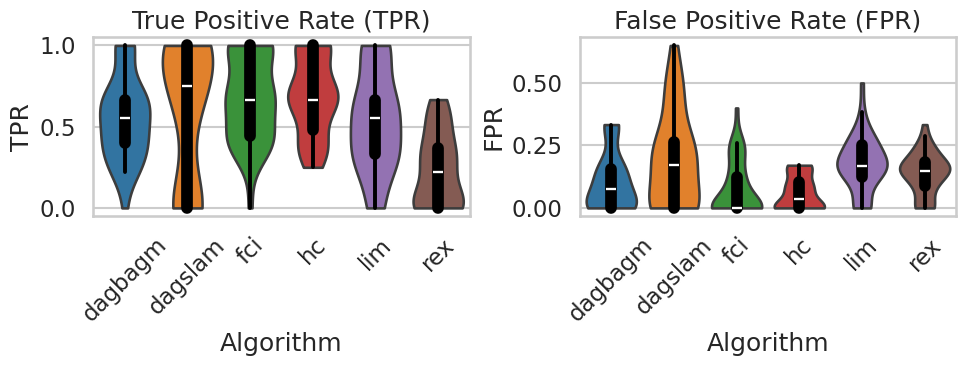

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")

order = sorted(all_scores["algo"].unique())
palette = sns.color_palette("tab10")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

sns.violinplot(
    data=all_scores,
    x="algo", y="TPR",
    order=order,
    inner="box",    #boxplot embedded in violin     
    cut=0,
    palette=palette,
    ax=axes[0],
    inner_kws=dict(color="black")
)
axes[0].set_title("True Positive Rate (TPR)")
axes[0].set_xlabel("Algorithm")
axes[0].set_ylabel("TPR")
axes[0].tick_params(axis="x", rotation=45) #rotate x labels to prevent overlap

sns.violinplot(
    data=all_scores,
    x="algo", y="FPR",
    order=order,
    inner="box",
    cut=0,
    palette=palette,
    ax=axes[1],
    inner_kws=dict(color="black")
)
axes[1].set_title("False Positive Rate (FPR)")
axes[1].set_xlabel("Algorithm")
axes[1].set_ylabel("FPR")
axes[1].tick_params(axis="x", rotation=45) #rotate x labels to prevent overlap

plt.tight_layout()
plt.savefig("tpr_fpr_violinplots.png", dpi=600, bbox_inches="tight")
plt.show()


/tmp/dcs-tmp.u2200504/ipykernel_714460/4062091071.py:6: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.scatterplot(


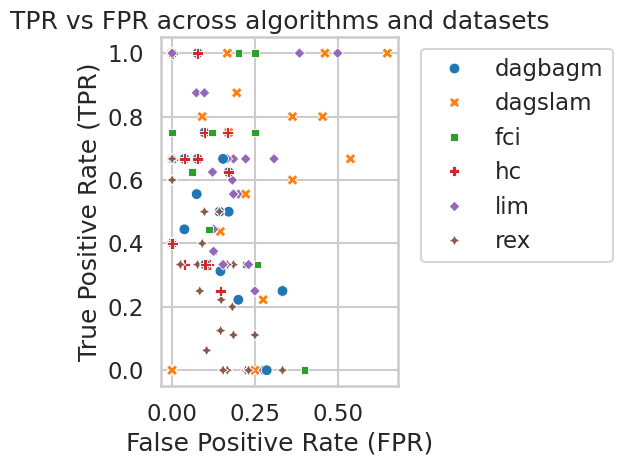

In [25]:
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(6, 5))
palette = sns.color_palette("tab10")

sns.scatterplot(
    data=all_scores,
    x="FPR", y="TPR",
    hue="algo",
    style="algo",
    palette = sns.color_palette("tab10"),
    s=60
)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("TPR vs FPR across algorithms and datasets")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("tpr_fpr_scatter.png",dpi=600, bbox_inches="tight")
plt.show()

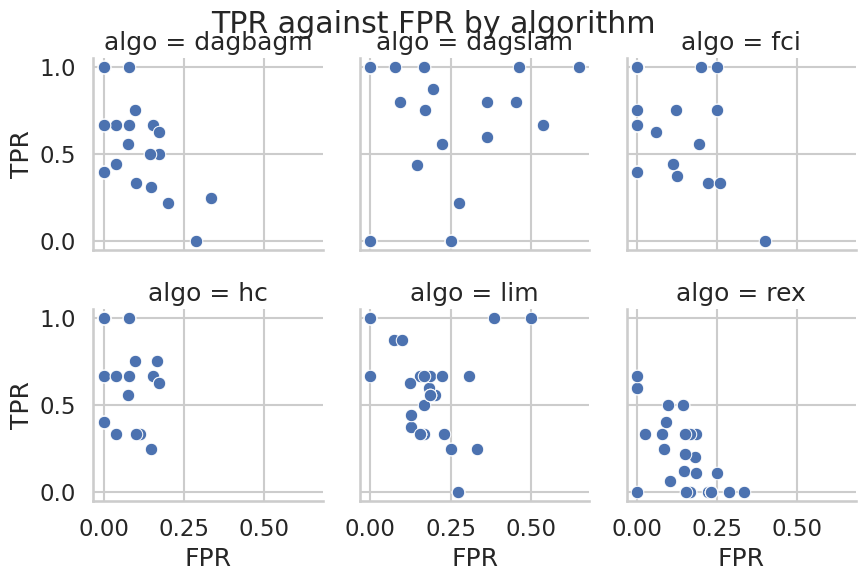

In [27]:
palette = sns.color_palette("tab10")

g = sns.FacetGrid(
    all_scores,
    col="algo",
    col_wrap=3,
    height=3,
    palette = sns.color_palette("tab10"),
    sharex=True,
    sharey=True
)
g.map_dataframe(sns.scatterplot, x="FPR", y="TPR")
g.set_axis_labels("FPR", "TPR")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("TPR against FPR by algorithm")
plt.show()


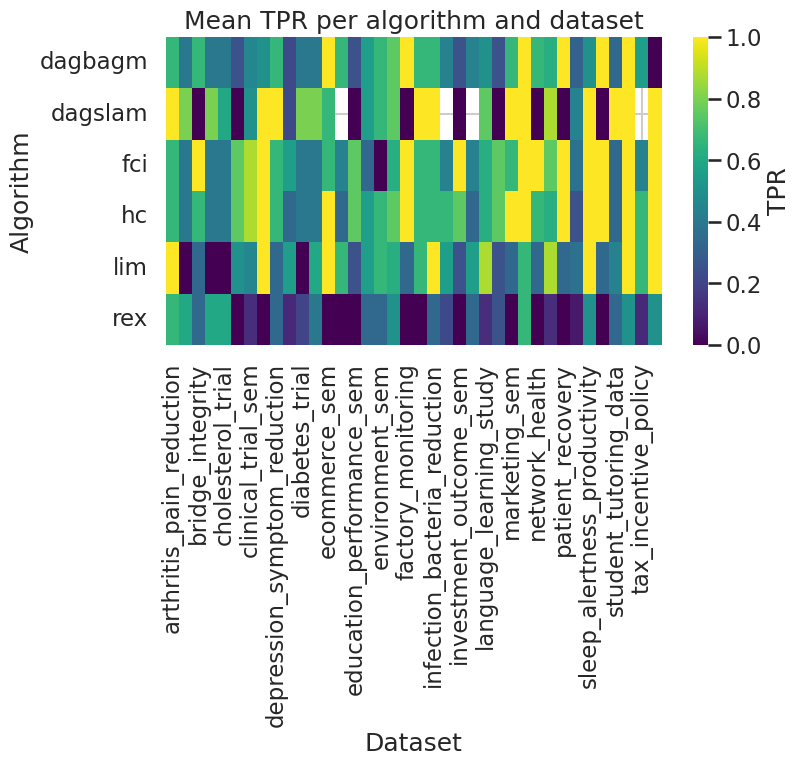

In [31]:
import pandas as pd

tpr_table = (
    all_scores
    .groupby(["algo", "dataset"])["TPR"]
    .mean()
    .unstack("dataset")
)

fpr_table = (
    all_scores
    .groupby(["algo", "dataset"])["FPR"]
    .mean()
    .unstack("dataset")
)

shd_table = (
    all_scores
    .groupby(["algo", "dataset"])["SHD"]
    .mean()
    .unstack("dataset")
)


plt.figure(figsize=(8, 4))
sns.heatmap(
    tpr_table,
    #annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "TPR"}
)
plt.xlabel("Dataset")
plt.ylabel("Algorithm")
plt.title("Mean TPR per algorithm and dataset")
plt.show()
